In [7]:
!pip install -q tf_keras rioxarray rasterio

In [8]:
import os
# Force legacy Keras 2 behaviour. Current TF ships Keras 3 by default, which
# breaks this codebase's private optimizer-internals usage and the
# unmaintained `segmentation_models` package -- tf_keras is TF's official
# compatibility shim for exactly this situation, same fix already applied
# in predictor.py.
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import sys
import numpy as np
import pandas as pd
import PIL
import requests
import tensorflow as tf
import tf_keras as keras
from tf_keras.models import *
from tf_keras.layers import *
from tf_keras.optimizers import *
from tf_keras.losses import *
from tf_keras import backend as K
from tf_keras.callbacks import ModelCheckpoint
from tf_keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import *


In [9]:
# Specify whether to download data or read in, and locate the dataset
download = False

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    # Path to the data.rar you uploaded to Drive (adjust if yours lives elsewhere)
    DRIVE_RAR_PATH = "/content/drive/MyDrive/COMP0173/data.rar"
else:
    base_dir = "./Amazon Forest Dataset/"

# NOTE: the dataset's actual folder names on disk are lowercase
# (training/ validation/ test/), not the Training/Validation/Test casing
# used in the original Experimentation.ipynb -- paths below use the
# lowercase form to match.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# Extract data.rar onto Colab's local disk (fast, and avoids relying on a
# multi-thousand-file Drive folder upload, which is fragile and slow to
# read from once mounted). Only needs to run once per Colab session.
import shutil
import os

if IN_COLAB:
    LOCAL_EXTRACT_DIR = "/content/amazon_data/"

    if not os.path.exists(LOCAL_EXTRACT_DIR):
        shutil.copy(DRIVE_RAR_PATH, "/content/data.rar")
        os.makedirs(LOCAL_EXTRACT_DIR, exist_ok=True)
        !apt-get -qq install -y unrar > /dev/null
        !unrar x -o+ /content/data.rar "{LOCAL_EXTRACT_DIR}" > /dev/null

    # The archive may extract into a nested top-level folder (e.g.
    # "Amazon Forest Dataset/") -- find whichever directory under
    # LOCAL_EXTRACT_DIR actually contains a "training" subfolder, rather
    # than hardcoding the exact name.
    base_dir = None
    for root, dirs, files in os.walk(LOCAL_EXTRACT_DIR):
        if 'training' in [d.lower() for d in dirs]:
            base_dir = root.rstrip('/') + '/'
            break

    assert base_dir is not None, "Could not find a 'training' folder anywhere under the extracted data -- run `!find /content/amazon_data | head -50` to inspect the extracted structure."
    print(f"base_dir set to: {base_dir}")


base_dir set to: /content/amazon_data/Amazon Forest Dataset/


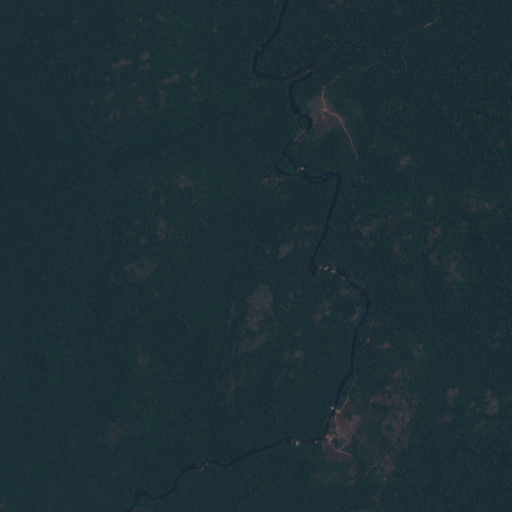

In [11]:
resolve_dir_preview = [d for d in os.listdir(base_dir) if d.lower() == 'training'][0]
PIL.Image.open(r"{}/{}/images/Amazon_1154.tiff_40.tiff".format(base_dir.rstrip('/'), resolve_dir_preview))


## Data ingestion and preprocessing

In [12]:
# Ingest images
#
# Folder casing for the top-level splits (Training/Validation/Test) differs
# between sources -- data.rar (extracted on Colab) uses capitalised names,
# while an already-extracted local copy on Mac has been seen with lowercase
# names. Resolve case-insensitively instead of hardcoding one casing.
def resolve_dir(base, name):
    matches = [d for d in os.listdir(base) if d.lower() == name.lower()]
    if not matches:
        raise FileNotFoundError(f"No folder matching '{name}' (case-insensitive) under {base}")
    return os.path.join(base, matches[0]) + '/'

training_dir = resolve_dir(base_dir, 'training')
validation_dir = resolve_dir(base_dir, 'validation')
test_dir = resolve_dir(base_dir, 'test')

## Training images
training_images_list = os.listdir(r"{}images/".format(training_dir))
training_masks_list = []
training_images = []
for n in training_images_list:
  im = PIL.Image.open(r"{}images/{}".format(training_dir, n))
  training_images.append(im)
  training_masks_list.append(n[:-5] + '.png')

## Training masks
training_masks = []
for n in training_masks_list:
  im = PIL.Image.open(r"{}masks/{}".format(training_dir, n))
  training_masks.append(im)

## Test images (no ground-truth masks are provided for this split)
test_images_list = os.listdir(test_dir)
test_images = []
for n in test_images_list:
  im = PIL.Image.open(r"{}{}".format(test_dir, n))
  test_images.append(im)

## Validation images
validation_images_list = os.listdir(r"{}images/".format(validation_dir))
validation_masks_list = []
validation_images = []
for n in validation_images_list:
  im = PIL.Image.open(r"{}images/{}".format(validation_dir, n))
  validation_images.append(im)
  validation_masks_list.append(n[:-5] + '.png')

## Validation masks
validation_masks = []
for n in validation_masks_list:
  im = PIL.Image.open(r"{}masks/{}".format(validation_dir, n))
  validation_masks.append(im)

print(f"training: {len(training_images)} images, validation: {len(validation_images)} images, test: {len(test_images)} images")


training: 30 images, validation: 15 images, test: 15 images


In [13]:
# Pre-process data: normalise and reshape
for i in range(len(training_images)):
  training_images[i] = np.array(training_images[i]) / 255
  training_images[i] = training_images[i].reshape(512, 512, 3)
  training_images[i] = training_images[i].astype('float32')

for i in range(len(training_masks)):
  training_masks[i] = (np.array(training_masks[i]) - 1)
  training_masks[i] = training_masks[i][:512, :512]
  training_masks[i] = training_masks[i].reshape(512, 512, 1)
  training_masks[i] = training_masks[i].astype('int')

for i in range(len(validation_images)):
  validation_images[i] = np.array(validation_images[i]) / 255
  validation_images[i] = validation_images[i].reshape(1, 512, 512, 3)
  validation_images[i] = validation_images[i].astype('float32')

for i in range(len(validation_masks)):
  validation_masks[i] = np.array(validation_masks[i]) - 1
  validation_masks[i] = validation_masks[i][:512, :512]
  validation_masks[i] = validation_masks[i].reshape(1, 512, 512, 1)
  validation_masks[i] = validation_masks[i].astype('int')

for i in range(len(test_images)):
  test_images[i] = np.array(test_images[i]) / 255
  test_images[i] = test_images[i].reshape(1, 512, 512, 3)
  test_images[i] = test_images[i].astype('float32')

# Move 5 training images into the validation set, as in the original experiment
for i in range(25, 30):
  validation_images.append(training_images[i].reshape(1, 512, 512, 3))
  validation_masks.append(training_masks[i].reshape(1, 512, 512, 1))

training_images = training_images[0:25]
training_masks = training_masks[0:25]

print(f"final split -- training: {len(training_images)}, validation: {len(validation_images)}, test: {len(test_images)}")


final split -- training: 25, validation: 20, test: 15


## Data augmentation generator

In [14]:
#
# Data loader/generator from: https://github.com/bragagnololu/UNet-defmapping.git
#

def adjustData(img, mask, num_class):
    mask[mask > 0.5] = 1  # FOREST
    mask[mask <= 0.5] = 0  # NON-FOREST
    return (img, mask)

def trainGenerator(batch_size,
                    image_array,
                    mask_array,
                    aug_dict,
                    image_save_prefix="image",
                    mask_save_prefix="mask",
                    num_class=2,
                    save_to_dir=None,
                    target_size=(512, 512),
                    seed=1):

    image_datagen = ImageDataGenerator(**aug_dict)
    mask_datagen = ImageDataGenerator(**aug_dict)

    image_generator = image_datagen.flow(image_array, batch_size=batch_size,
                                          save_to_dir=save_to_dir,
                                          save_prefix=image_save_prefix, seed=seed)

    mask_generator = mask_datagen.flow(mask_array, batch_size=batch_size,
                                        save_to_dir=save_to_dir,
                                        save_prefix=mask_save_prefix, seed=seed)

    train_generator = zip(image_generator, mask_generator)

    for (img, mask) in train_generator:
        img, mask = adjustData(img, mask, num_class)
        yield (img, mask)

t_images = np.stack(training_images)
t_masks = np.stack(training_masks)

validation_df = tf.data.Dataset.from_tensor_slices((validation_images, validation_masks))

data_gen_args = dict(rotation_range=180,
                      width_shift_range=0.25,
                      height_shift_range=0.25,
                      shear_range=0.25,
                      zoom_range=0.25,
                      horizontal_flip=True,
                      vertical_flip=True,
                      fill_mode='reflect')


## Model architecture -- U-Net and Attention U-Net

In [15]:
'''
  Convolutional block with a single conv layer and activation
'''
def convBlock(input, filters, kernel, kernel_init='he_normal', act='relu', transpose=False):
  if transpose == False:
    conv = Conv2D(filters, kernel, padding='same', kernel_initializer=kernel_init)(input)
  else:
    conv = Conv2DTranspose(filters, kernel, padding='same', kernel_initializer=kernel_init)(input)
  conv = Activation(act)(conv)
  return conv

'''
  Convolutional block with two conv layers and two activation layers
'''
def convBlock2(input, filters, kernel, kernel_init='he_normal', act='relu', transpose=False):
  if transpose == False:
    conv = Conv2D(filters, kernel, padding='same', kernel_initializer=kernel_init)(input)
    conv = Activation(act)(conv)
    conv = Conv2D(filters, kernel, padding='same', kernel_initializer=kernel_init)(conv)
    conv = Activation(act)(conv)
  else:
    conv = Conv2DTranspose(filters, kernel, padding='same', kernel_initializer=kernel_init)(input)
    conv = Activation(act)(conv)
    conv = Conv2DTranspose(filters, kernel, padding='same', kernel_initializer=kernel_init)(conv)
    conv = Activation(act)(conv)
  return conv

'''
  U-Net model (baseline, no attention gates)
'''
def UNet(trained_weights=None, input_size=(512, 512, 3), drop_rate=0.25, lr=0.0001):
    inputs = Input(input_size, batch_size=1)

    conv1 = convBlock(inputs, 64, 3)
    conv1 = convBlock(conv1, 64, 3)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = convBlock(pool1, 128, 3)
    conv2 = convBlock(conv2, 128, 3)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = convBlock(pool2, 256, 3)
    conv3 = convBlock(conv3, 256, 3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

    conv4 = convBlock(pool3, 512, 3)
    conv4 = convBlock(conv4, 512, 3)
    pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)

    conv5 = convBlock(pool4, 1024, 3)
    conv5 = convBlock(conv5, 1024, 3)

    up6 = Conv2DTranspose(512, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv5)
    merge6 = concatenate([conv4, up6])
    conv6 = convBlock(merge6, 512, 3)
    conv6 = convBlock(conv6, 512, 3)

    up7 = Conv2DTranspose(256, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv6)
    merge7 = concatenate([conv3, up7])
    conv7 = convBlock(merge7, 256, 3)
    conv7 = convBlock(conv7, 256, 3)

    up8 = Conv2DTranspose(128, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv7)
    merge8 = concatenate([conv2, up8])
    conv8 = convBlock(merge8, 128, 3)
    conv8 = convBlock(conv8, 128, 3)

    up9 = Conv2DTranspose(64, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv8)
    merge9 = concatenate([conv1, up9])
    conv9 = convBlock(merge9, 64, 3)
    conv9 = convBlock(conv9, 64, 3)

    out = convBlock(conv9, 1, 1, act='sigmoid')
    model = Model(inputs, out)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss=binary_crossentropy, metrics=['accuracy', 'mse'])

    if trained_weights is not None:
        model.load_weights(trained_weights)
    return model

'''
  Attention gate/block
'''
def attention_block(x, gating, inter_shape, drop_rate=0.25):
    shape_x = K.int_shape(x)
    shape_g = K.int_shape(gating)

    theta_x = Conv2D(inter_shape, kernel_size=1, strides=1, padding='same', kernel_initializer='he_normal', activation=None)(x)
    theta_x = MaxPooling2D((2, 2))(theta_x)
    shape_theta_x = K.int_shape(theta_x)

    phi_g = Conv2D(inter_shape, kernel_size=1, strides=1, padding='same', kernel_initializer='he_normal', activation=None)(gating)

    concat_xg = add([phi_g, theta_x])
    act_xg = Activation('relu')(concat_xg)

    psi = Conv2D(1, kernel_size=1, strides=1, padding='same', kernel_initializer='he_normal', activation=None)(act_xg)
    sigmoid_xg = Activation('sigmoid')(psi)
    shape_sigmoid = K.int_shape(sigmoid_xg)

    upsample_psi = UpSampling2D(interpolation='bilinear', size=(shape_x[1] // shape_sigmoid[1], shape_x[2] // shape_sigmoid[2]))(sigmoid_xg)
    upsample_psi = tf.broadcast_to(upsample_psi, shape=shape_x)
    y = multiply([upsample_psi, x])
    return y

'''
  Attention U-Net model
'''
def UNetAM(trained_weights=None, input_size=(512, 512, 3), drop_rate=0.25, lr=0.0001, filter_base=16):
    inputs = Input(input_size, batch_size=1)

    conv = convBlock2(inputs, filter_base, 3)

    conv0 = MaxPooling2D(pool_size=(2, 2))(conv)
    conv0 = convBlock2(conv0, 2 * filter_base, 3)

    pool0 = MaxPooling2D(pool_size=(2, 2))(conv0)
    conv1 = convBlock2(pool0, 4 * filter_base, 3)

    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)
    conv2 = convBlock2(pool1, 8 * filter_base, 3)

    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
    conv3 = convBlock2(pool2, 16 * filter_base, 3)

    up4 = Conv2DTranspose(8 * filter_base, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv3)
    merge4 = attention_block(conv2, conv3, 8 * filter_base, drop_rate)
    conv4 = concatenate([up4, merge4])
    conv4 = convBlock2(conv4, 8 * filter_base, 3)

    up5 = Conv2DTranspose(4 * filter_base, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv4)
    merge5 = attention_block(conv1, conv4, 4 * filter_base, drop_rate)
    conv5 = concatenate([up5, merge5])
    conv5 = convBlock2(conv5, 4 * filter_base, 3)

    up6 = Conv2DTranspose(2 * filter_base, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv5)
    merge6 = attention_block(conv0, conv5, 2 * filter_base, drop_rate)
    conv6 = concatenate([up6, merge6])
    conv6 = convBlock2(conv6, 2 * filter_base, 3)

    up7 = Conv2DTranspose(1 * filter_base, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv6)
    merge7 = attention_block(conv, conv6, 1 * filter_base, drop_rate)
    conv7 = concatenate([up7, merge7])
    conv7 = concatenate([up7, conv])
    conv7 = convBlock2(conv7, 1 * filter_base, 3)

    out = convBlock(conv7, 1, 1, act='sigmoid')
    model = Model(inputs, out)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss=binary_crossentropy, metrics=['accuracy', 'mse'])

    if trained_weights is not None:
        model.load_weights(trained_weights)
    return model


## Training config

Edit these values to reproduce the original experiment, or to try a
different configuration later (e.g. for training on your own dataset).
The values below match the original `Experimentation.ipynb` Attention U-Net run.

In [16]:
# Hyperparameters -- change these for a different training config
EPOCHS = 50
STEPS_PER_EPOCH = 100
LEARNING_RATE = 0.0005
FILTER_BASE = 16
MODEL_OUT_PATH = "unet-attention-3d-reproduced.hdf5"

# Where to also save a copy of the trained model (Drive, if on Colab)
DRIVE_SAVE_DIR = "/content/drive/MyDrive/COMP0173/" if IN_COLAB else "./"


## Train Attention U-Net

In [17]:
model_attention_unet = UNetAM(lr=LEARNING_RATE, filter_base=FILTER_BASE)
save_model_am = ModelCheckpoint(MODEL_OUT_PATH, monitor='val_accuracy', verbose=1, save_best_only=True)
train = trainGenerator(1, t_images, t_masks, data_gen_args, save_to_dir=None)

history = model_attention_unet.fit(train, steps_per_epoch=STEPS_PER_EPOCH, epochs=EPOCHS,
                                    validation_data=validation_df, callbacks=[save_model_am])

np.save(MODEL_OUT_PATH.replace('.hdf5', '-history.npy'), history.history)


Epoch 1/50
100/100 [==============================] - ETA: 0s - loss: 0.5373 - accuracy: 0.7530 - mse: 0.1799
Epoch 1: val_accuracy improved from -inf to 0.89585, saving model to unet-attention-3d-reproduced.hdf5


/usr/local/lib/python3.13/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


100/100 [==============================] - 28s 105ms/step - loss: 0.5373 - accuracy: 0.7530 - mse: 0.1799 - val_loss: 0.2627 - val_accuracy: 0.8958 - val_mse: 0.0780
Epoch 2/50
100/100 [==============================] - ETA: 0s - loss: 0.2915 - accuracy: 0.9019 - mse: 0.0820
Epoch 2: val_accuracy did not improve from 0.89585
100/100 [==============================] - 11s 114ms/step - loss: 0.2915 - accuracy: 0.9019 - mse: 0.0820 - val_loss: 0.2514 - val_accuracy: 0.8948 - val_mse: 0.0758
Epoch 3/50
100/100 [==============================] - ETA: 0s - loss: 0.2042 - accuracy: 0.9265 - mse: 0.0569
Epoch 3: val_accuracy improved from 0.89585 to 0.91369, saving model to unet-attention-3d-reproduced.hdf5
100/100 [==============================] - 12s 118ms/step - loss: 0.2042 - accuracy: 0.9265 - mse: 0.0569 - val_loss: 0.2122 - val_accuracy: 0.9137 - val_mse: 0.0631
Epoch 4/50
100/100 [==============================] - ETA: 0s - loss: 0.2003 - accuracy: 0.9309 - mse: 0.0533
Epoch 4: val_ac

In [21]:
# Copy the trained model and training history to Drive so they survive
# a Colab runtime disconnect/reset
import shutil

if IN_COLAB:
    shutil.copy(MODEL_OUT_PATH, DRIVE_SAVE_DIR)
    shutil.copy(MODEL_OUT_PATH.replace('.hdf5', '-history.npy'), DRIVE_SAVE_DIR)
    print(f"Saved model and history to {DRIVE_SAVE_DIR}")


Saved model and history to /content/drive/MyDrive/COMP0173/


## Evaluate and check reproduction validity

Metric functions are copied from the original `Experimentation.ipynb`.
We evaluate on the validation set (the RGB/3-band test split has no
ground-truth masks in the original dataset, so it can't be scored --
this matches the original experiment, which also has no `metrics_3d_test.csv`).

In [26]:
import os
REPO_DIR = "/content/COMP0173_poster_pre"
if not os.path.exists(REPO_DIR):
    !git clone -q https://github.com/jy-gfm/COMP0173_poster_pre.git {REPO_DIR}
os.chdir(REPO_DIR)


In [27]:
'''
  Metric functions for evaluation (from Experimentation.ipynb)
'''
def score_eval(model, image, mask):
  if type(image) != list:
    reconstruction = model.predict(image).reshape(mask.shape[1], mask.shape[2])
    reconstruction = np.round(reconstruction).flatten()
    return accuracy_score(mask.flatten(), reconstruction)
  else:
    scores = []
    for i in range(len(image)):
      reconstruction = model.predict(image[i].reshape(1, 512, 512, 3))
      reconstruction = np.round(reconstruction).flatten()
      scores.append(accuracy_score(mask[i].flatten(), reconstruction))
    return scores

def recall_eval(model, image, mask):
  recall = []
  for i in range(len(image)):
      reconstruction = model.predict(image[i]).reshape(mask[i].shape[1], mask[i].shape[2])
      reconstruction = np.round(reconstruction).flatten()
      recall.append(recall_score(mask[i].flatten(), reconstruction, average='weighted'))
  return recall

def precision_eval(model, image, mask):
  precision = []
  for i in range(len(image)):
      reconstruction = model.predict(image[i]).reshape(mask[i].shape[1], mask[i].shape[2])
      reconstruction = np.round(reconstruction).flatten()
      precision.append(precision_score(mask[i].flatten(), reconstruction, average='weighted'))
  return precision

def f1_score_eval_basic(precision, recall):
    prec = np.mean(precision)
    rec = np.mean(recall)
    if prec + rec == 0:
        return 0
    return 2 * (prec * rec) / (prec + rec)


In [28]:
am_unet_score = score_eval(model_attention_unet, validation_images, validation_masks)
am_unet_precision = precision_eval(model_attention_unet, validation_images, validation_masks)
am_unet_recall = recall_eval(model_attention_unet, validation_images, validation_masks)
am_unet_f1 = f1_score_eval_basic(am_unet_precision, am_unet_recall)

reproduced_metrics = {
    "accuracy": np.mean(am_unet_score),
    "precision": np.mean(am_unet_precision),
    "recall": np.mean(am_unet_recall),
    "f1_score": am_unet_f1,
}
reproduced_metrics


1/1 [==============================] - 0s 28ms/step


{'accuracy': np.float64(0.9538862228393554),
 'precision': np.float64(0.9597261239107114),
 'recall': np.float64(0.9538862228393554),
 'f1_score': np.float64(0.9567972623632025)}

In [29]:
# Compare against the original paper's checked-in results (metrics/metrics_3d.csv)
original_metrics = pd.read_csv("metrics/metrics_3d.csv", index_col=0)
original_am_unet = original_metrics[original_metrics["classifier"] == "Attention U-Net"].iloc[0]

comparison = pd.DataFrame({
    "original": [original_am_unet["accuracy"], original_am_unet["precision"], original_am_unet["recall"], original_am_unet["f1_score"]],
    "reproduced": [reproduced_metrics["accuracy"], reproduced_metrics["precision"], reproduced_metrics["recall"], reproduced_metrics["f1_score"]],
}, index=["accuracy", "precision", "recall", "f1_score"])
comparison["abs_diff"] = (comparison["original"] - comparison["reproduced"]).abs()
comparison["pct_diff"] = comparison["abs_diff"] / comparison["original"] * 100

print(comparison)

# Rule of thumb: within the original's reported std dev / a few percentage
# points is a valid reproduction, given the small dataset (30 training tiles)
# and stochastic training (augmentation, weight init).
TOLERANCE_PCT = 5
if (comparison["pct_diff"] <= TOLERANCE_PCT).all():
    print(f"\nReproduction looks VALID -- all metrics within {TOLERANCE_PCT}% of the original.")
else:
    print(f"\nSome metrics differ by more than {TOLERANCE_PCT}% -- inspect training curves and dataset split before concluding the reproduction failed.")


           original  reproduced  abs_diff  pct_diff
accuracy   0.952631    0.953886  0.001255  0.131724
precision  0.957403    0.959726  0.002323  0.242624
recall     0.952631    0.953886  0.001255  0.131724
f1_score   0.955011    0.956797  0.001786  0.187005

Reproduction looks VALID -- all metrics within 5% of the original.
